In [20]:
%%capture
%run script_nettoyage.ipynb

In [21]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import random

random.seed(1)

# copie
df = df_freq_totale.copy()

# colonnes non binaires
colonnes_non_binaires = [
    'REF DU MUSEE', 'NOMREG', 'NOM DU MUSEE', 'VILLE',
    'Fréquentation', 'IDMuseofile', 'annee', 'frequentation',
    'speciale', 'freq_net', 'Statut', 'Domaine_thematique'
]

# colonnes binaires thématiques
colonnes_binaires = [col for col in df.columns if col not in colonnes_non_binaires]

# types de variables
variables_numeriques = ['freq_net']
variables_categorielles = ['annee', 'NOMREG']

# conversions
df['freq_net'] = pd.to_numeric(df['freq_net'], errors='coerce')

# sous-table
X = df[variables_numeriques + variables_categorielles + colonnes_binaires].copy()

# NA
for col in variables_numeriques:
    X[col] = X[col].fillna(X[col].median())

for col in variables_categorielles:
    X[col] = X[col].fillna("Inconnu").astype(str)

for col in colonnes_binaires:
    X[col] = pd.to_numeric(X[col], errors='coerce').fillna(0)

# prétraitement
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), variables_numeriques),
        ('cat', OneHotEncoder(handle_unknown='ignore'), variables_categorielles),
        ('bin', 'passthrough', colonnes_binaires)
    ]
)

X_prep = preprocessor.fit_transform(X)

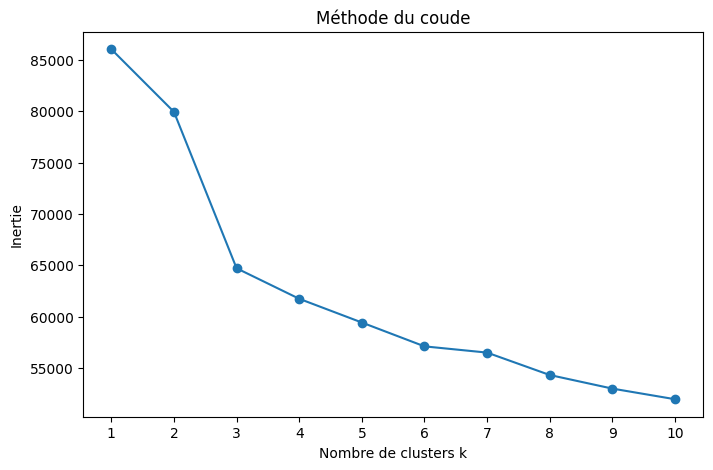

In [22]:
inerties = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_prep)
    inerties.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inerties, marker='o')
plt.xlabel("Nombre de clusters k")
plt.ylabel("Inertie")
plt.title("Méthode du coude")
plt.xticks(K)
plt.show()

La "règle du coude" nous permet de choisir le nombre de clusters. Ici nous en choisissons 3.

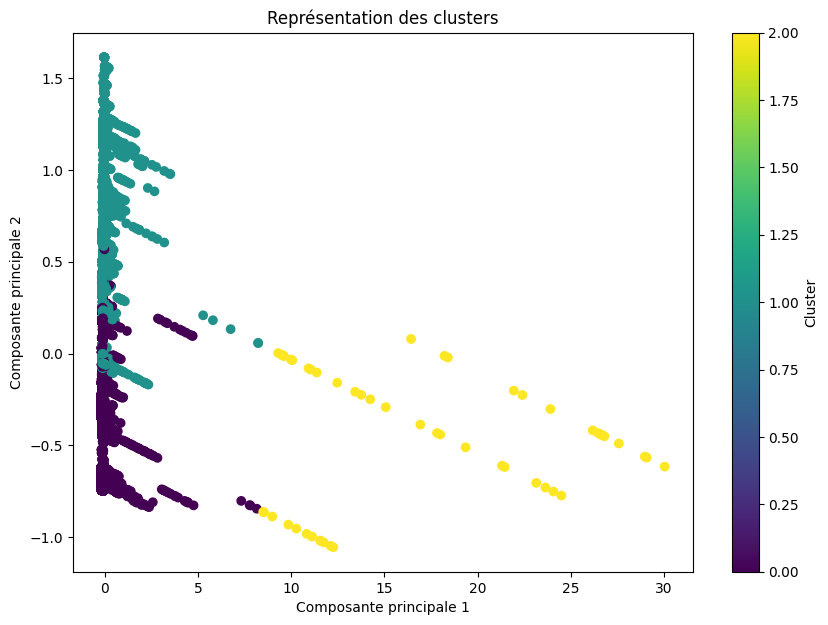

                                      NOM DU MUSEE annee  \
0                                    Musée du Brou  2001   
1            Musée Départemental des Pays De l'Ain  2001   
2  Musée de la Société d'Histoire et d'Archéologie  2001   
3                 Musée Départemental du Revermont  2001   
4                              Musée Archéologique  2001   

                 NOMREG  Statut  freq_net  cluster  
0  AUVERGNE-RHÔNE-ALPES  Ouvert   74056.0        1  
1  AUVERGNE-RHÔNE-ALPES      NA       NaN        1  
2  AUVERGNE-RHÔNE-ALPES  Ouvert     100.0        0  
3  AUVERGNE-RHÔNE-ALPES  Ouvert   22234.0        0  
4  AUVERGNE-RHÔNE-ALPES  Ouvert     204.0        0  


In [23]:
# clustering final
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=20)
df['cluster'] = kmeans_final.fit_predict(X_prep)

# réduction en 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_prep)

# graphique
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'])
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Représentation des clusters")
plt.colorbar(scatter, label="Cluster")
plt.show()

print(df[['NOM DU MUSEE', 'annee', 'NOMREG', 'Statut', 'freq_net', 'cluster']].head())

Un cluster semble se distinguer des autres par rapport à la composante principale 1 et les deux autres se différencient sur la composante 2.

In [ ]:
score_silhouette = silhouette_score(X_prep, df['cluster'])
print("Score de silhouette :", score_silhouette)

Le score silhouette est très faible ce qui indique que les clusters ne sont pas très bien distincts.

Combien d'observations sont présentes dans chaque cluster ?

In [24]:
df['cluster'].value_counts().sort_index()

cluster
0    11092
1     8709
2       55
Name: count, dtype: int64

Nous remarquons que le cluster 2 est beaucoup plus petit que les 2 autres.

In [25]:
# PCA sur les données préparées
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_prep)

# noms des variables après prétraitement
feature_names = preprocessor.get_feature_names_out()

# loadings = contribution des variables aux composantes
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=['PC1', 'PC2']
)

top_pc1 = loadings.assign(importance=loadings['PC1'].abs()) \
                  .sort_values('importance', ascending=False)

top_pc2 = loadings.assign(importance=loadings['PC2'].abs()) \
                  .sort_values('importance', ascending=False)

print("Top 10 PC1")
print(top_pc1[['PC1', 'importance']].head(10))

print("\nTop 10 PC2")
print(top_pc2[['PC2', 'importance']].head(10))

Top 10 PC1
                                       PC1  importance
num__freq_net                     0.995086    0.995086
cat__NOMREG_ÎLE-DE-France         0.070782    0.070782
bin__Arts_decoratifs              0.042194    0.042194
bin__Beaux_arts                   0.036192    0.036192
bin__Arts de l'Islam              0.023582    0.023582
bin__Art moderne et contemporain  0.017111    0.017111
bin__Sciences de la nature       -0.014533    0.014533
cat__NOMREG_OCCITANIE            -0.010207    0.010207
cat__NOMREG_AUVERGNE-RHÔNE-ALPES -0.009391    0.009391
cat__NOMREG_NOUVELLE-AQUITAINE   -0.008084    0.008084

Top 10 PC2
                                       PC2  importance
bin__Beaux_arts                   0.662961    0.662961
bin__Arts_decoratifs              0.524801    0.524801
bin__Archeologie                  0.389374    0.389374
bin__Art moderne et contemporain  0.289644    0.289644
bin__Asie                         0.127824    0.127824
bin__Oceanie                      0.102637

La composante principale 1 est portée par la région Ile de France. Les observations présentes dans le cluster portée par cette composante pourraient donc présenter des fréquentations très importantes.

In [26]:
resume_num = df.groupby('cluster').agg({
    'freq_net': ['mean', 'median']
})

print(resume_num)

             freq_net           
                 mean     median
cluster                         
0        3.495481e+04    10197.0
1        3.639867e+04    13023.0
2        5.289441e+06  4480081.0


L'hypothèse est bien vérifiée. Le cluster 2 est clairement composé d'observations ayant une fréquentation plus importante que les autres.

Les clusers 0 et 1 semblent se distinguer par rapport au domaine thématique et notamment aux beaux-art / arts. Vérifions cette hypothèse.

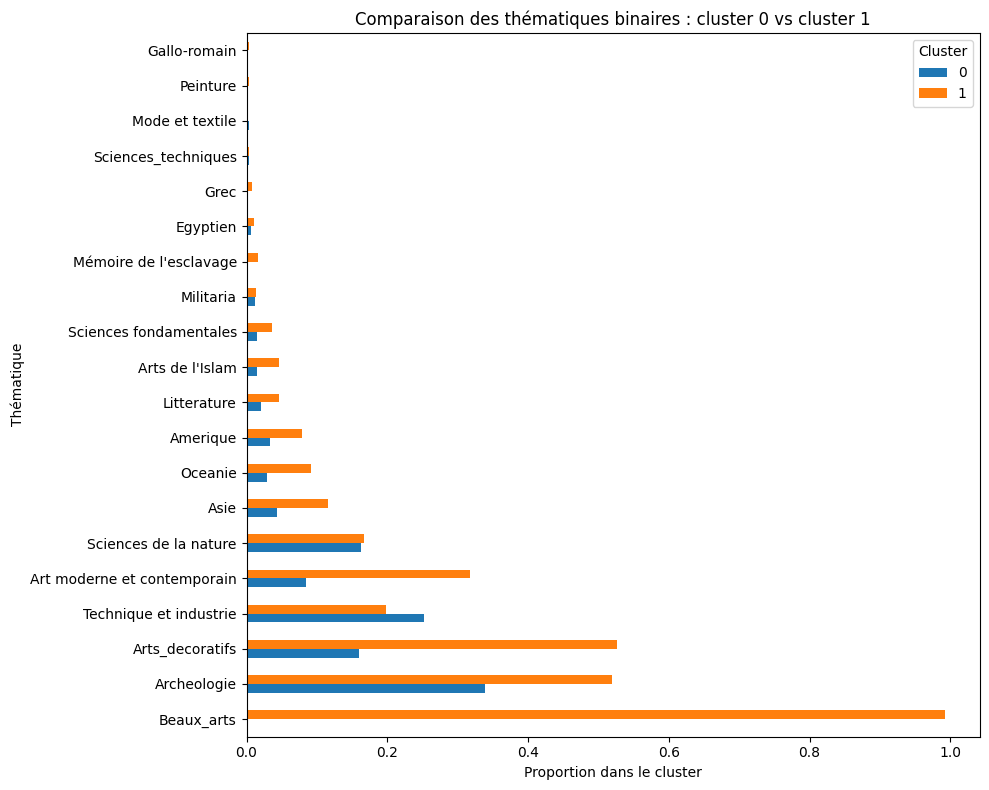

In [27]:
# moyenne des thématiques pour les clusters 0 et 1
themes_01 = df[df['cluster'].isin([0, 1])] \
    .groupby('cluster')[colonnes_binaires] \
    .mean() \
    .T

# option : ne garder que les thématiques les plus présentes au total
themes_01['moyenne_totale'] = themes_01.mean(axis=1)
themes_01 = themes_01.sort_values('moyenne_totale', ascending=False).head(20)
themes_01 = themes_01.drop(columns='moyenne_totale')

# graphique
ax = themes_01.plot(kind='barh', figsize=(10, 8))

plt.xlabel("Proportion dans le cluster")
plt.ylabel("Thématique")
plt.title("Comparaison des thématiques binaires : cluster 0 vs cluster 1")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

Le cluster 1 se distingue effectivement par les beaux-arts et arts en général. Le cluster 0 semble se distinguer par la technologie et la science.

L'année ne semble pas avoir d'influence sur le clustering. Vérifions cela.

In [29]:
table_annee_cluster = pd.crosstab(df['annee'], df['cluster'])
print(table_annee_cluster)

cluster    0    1  2
annee               
2001     693  546  2
2002     694  545  2
2003     694  545  2
2004     694  545  2
2005     694  544  3
2006     693  544  4
2007     693  544  4
2008     693  544  4
2009     693  544  4
2010     693  544  4
2011     693  544  4
2012     693  544  4
2013     693  544  4
2014     693  544  4
2015     693  544  4
2016     693  544  4


La répartition des clusters selon l'année est effectivement très stable.

cluster                        0     1   2
NOMREG                                    
AUVERGNE-RHÔNE-ALPES        1424   752   0
BOURGOGNE-FRANCHE-COMTE      720   896   0
BRETAGNE                     352   256   0
CENTRE-VAL DE LOIRE          576   464   0
CORSE                        112    48   0
GRAND EST                   1216   768   0
GUADELOUPE                    32    48   0
GUYANE                        48     0   0
HAUTS-DE-France              592   800   0
LA REUNION                    64    16   0
MARTINIQUE                    96    16   0
NORMANDIE                    688   784   0
NOUVELLE-AQUITAINE           928   848   0
OCCITANIE                   1472   672   0
PAYS DE LA LOIRE             512   384   0
PROVENCE-ALPES-CÔTE D'AZUR  1136   848   0
SAINT-PIERRE ET MIQUELON      16     0   0
ÎLE-DE-France               1108  1109  55
cluster                         0      1      2
NOMREG                                         
AUVERGNE-RHÔNE-ALPES        0.654  0.346  0.

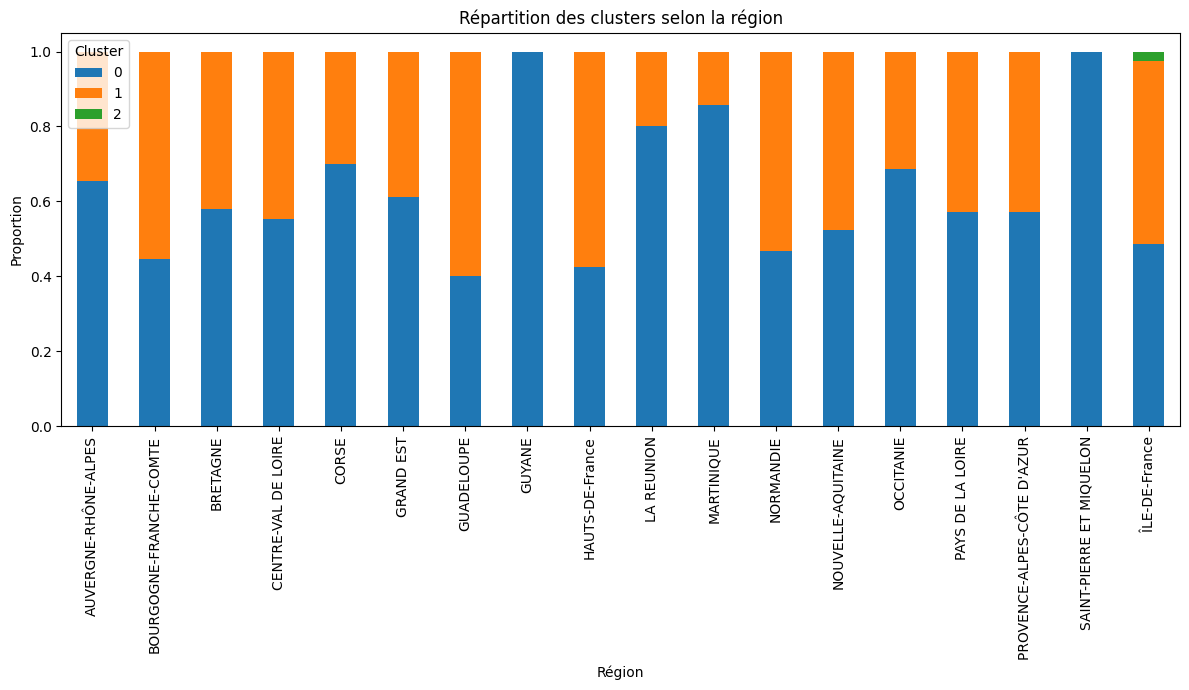

In [32]:
table_region_cluster = pd.crosstab(df['NOMREG'], df['cluster'])
print(table_region_cluster)

table_region_prop = pd.crosstab(
    df['NOMREG'],
    df['cluster'],
    normalize='index'
)

print(table_region_prop.round(3))

table_region_prop.plot(kind='bar', stacked=True, figsize=(12, 7))
plt.xlabel("Région")
plt.ylabel("Proportion")
plt.title("Répartition des clusters selon la région")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()